/tmp/ipykernel_2985010/2888280838.py:27: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  plt.tight_layout()


[]

/home/alexander.z/miniconda3/envs/gmx-plumed/lib/python3.10/site-packages/IPython/core/events.py:82: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  func(*args, **kwargs)
/home/alexander.z/miniconda3/envs/gmx-plumed/lib/python3.10/site-packages/IPython/core/pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


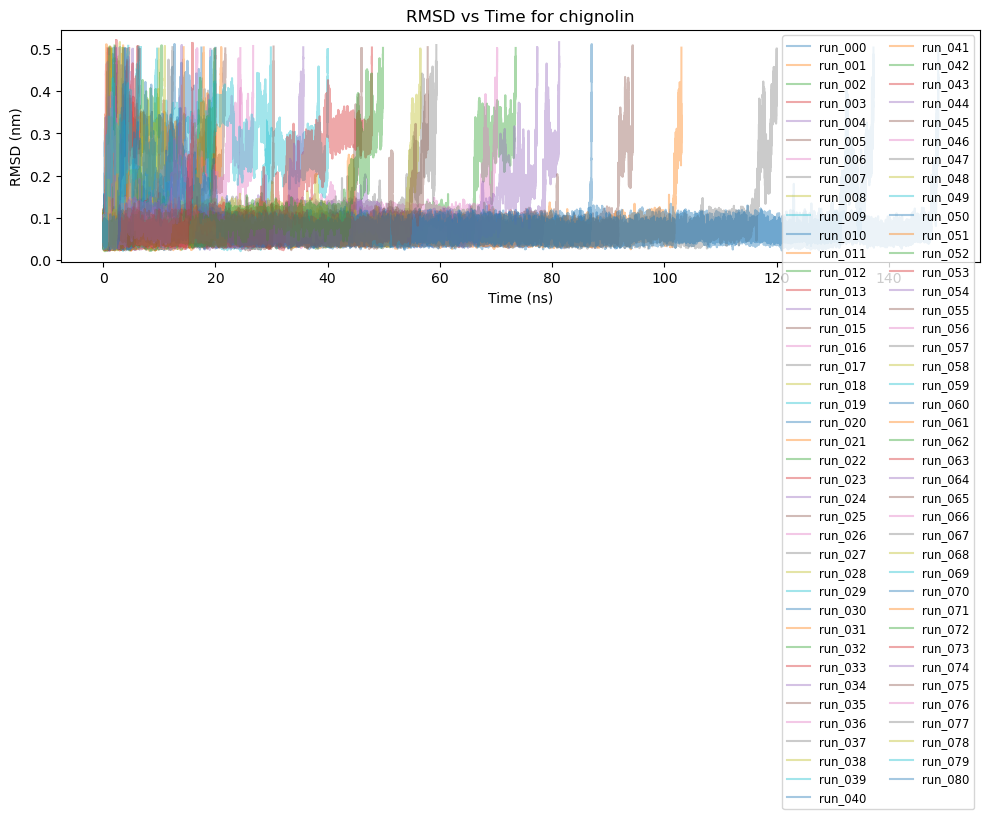

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

protein_name = "chignolin"
N = 80
base_path = Path(f"../../data/{protein_name}/output")
output_dir = Path("figures")
output_dir.mkdir(parents=True, exist_ok=True)

plt.figure(figsize=(10, 6))
for i in range(0, N + 1):
    run_name = f"run_{i:03}"
    colvar_file = base_path / run_name / f"HLDA_COLVAR_{i:03}"
    if not colvar_file.exists():
        continue
    with colvar_file.open() as f:
        header_line = next(line for line in f if line.startswith("#!"))
        headers = header_line.replace("#! FIELDS", "").strip().split()
    df = pd.read_csv(colvar_file, sep=r"\s+", comment="#", names=headers)
    plt.plot(df["time"] * 1e-3, df["rmsd"], label=run_name,alpha=0.4)

plt.xlabel("Time (ns)")
plt.ylabel("RMSD (nm)")
plt.title(f"RMSD vs Time for {protein_name}")
plt.legend(fontsize="small", ncol=2)
plt.tight_layout()
plt.plot()
